## `photoz_bias.ipynb`

-----------------------

This notebook measures and models the photoz galaxy bias given scale cuts.

In [1]:
import numpy as np 
import json
import importlib
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path

import src.statistics.inference as inference
import src.statistics.corrfiles as cf

# Methods:
----------

We use the [Euclid](https://arxiv.org/pdf/2208.10503) approach (derived from Schmidt+2013):

We use : 
$n_{p, m}(z_{j, t})\propto \frac{\bar{\omega}_{\rm{sp},\:m}(r,\:z_{j, t})}{\sqrt{\bar{\omega}_{\rm{ss}}(r,\:z_{j, t})\bar{\omega}_{\rm{pp},\:m}(r)}}$ with $\bar{\omega}_{xy}(r, z_j)=\int_{r_{min}}^{r_{max}}W(r)\omega_{xy}(r, z_j)$ the scale averaged two point correlation function between samples x, y.

- $z_{j, t}$ : center of the fine bin j for the t tracer (ELG, LRG ...)
- $m$ : id of the tomographic bin
- $s$ : spectroscopic sample
- $p$ : photometric sample

Cosmology used (for distances in $h^{-1}Mpc$) :
- $\Omega_c = 0.258868$ (cold dark matter density fraction)
- $\Omega_b = 0.048252$ (baryon density fraction)
- $\Omega_m=\Omega_c+\Omega_b$ (matter density fraction)
- $h = 0.6777$
- $H_0 = h * 100$
- $\sigma_8 = 0.8$
- $n_s = 0.95$

DES Y3 Approach :

-----------------

$n_{p, m}(z_{j, t})\propto\frac{\bar{\omega}_{\rm{sp},\:m}(r,\:z_{j, t})}{\sqrt{\bar{\omega}_{\rm{ss}}(r,\:z_{j, t})\bar{\omega}_{\rm{pp},\:m}(r, z_{j, t})\sigma_j}}$ with $\bar{\omega}_{xy}(r, z_j)=\int_{r_{min}}^{r_{max}}W(r)\omega_{xy}(r, z_j)$

This approach does not really work well due to the very high variations in $\sigma_j$ caused by the photometric method itself (redshift spikes)


In [2]:
ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/')
bins_hsc = np.arange(0.3, 1.8, 0.3)

markers = ['x', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']
colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
colors = [cmap(0.8) for cmap in colormaps]
tracers_dr1 = ['BGS_ANY', 'LRG', 'ELG_LOPnotqso', 'QSO']
tracers_dr2 = ['BGS_ANY', 'LRG', 'ELGnotqso', 'QSO']
tracers = ['BGS_ANY', 'LRG', 'ELGnotqso', 'ELG_LOPnotqso', 'QSO']
tracer_trad = {
    'BGS_ANY' : 'BGS',
    'LRG' : 'LRG',
    'ELGnotqso' : 'ELG',
    'ELG_LOPnotqso' : 'ELG-LOP',
    'QSO' : 'QSO',
}

In [3]:
stem = 'calibration'
path_dictionary = {
    'dr1' : {
        'HSC' : ROOT / stem / f'autos_HSC',
        'DESI_NGC' : ROOT / stem / 'dr1' / f'autos_NGC',
        'DESI_SGC' : ROOT / stem / 'dr1' /f'autos_SGC',
        'DESIxHSC' : ROOT / stem / 'dr1' / f'cross',
    },
    'dr2' : {
        'HSC' : ROOT / stem / f'autos_HSC',
        'DESI_NGC' : ROOT / stem / 'dr2' / f'autos_NGC',
        'DESI_SGC' : ROOT / stem / 'dr2' /f'autos_SGC',
        'DESIxHSC' : ROOT / stem / 'dr2' / f'cross',
    }
}
assert all([pv.exists() for p in path_dictionary.values() for pv in p.values()])

In [7]:
importlib.reload(inference)
fr_dr1 = cf.CorrFileReader(path_dictionary['dr1']['DESIxHSC'])
fr_dr2 = cf.CorrFileReader(path_dictionary['dr2']['DESIxHSC'])
bins_hsc = fr_dr1.get_bins('HSC')
bhsc_vals = (bins_hsc[1:] + bins_hsc[:-1])/2
scale_cut = [1, 5] #[.3, 3]
patches = [1,2,3,4]

results = {}

for bp, bhsc_z in enumerate(bhsc_vals, start=1):
    results[bp] = {t: [] for t in set(tracers)}
    print(f'\n Tomo bin {bp} at z {bhsc_z} \n')
    if bhsc_z < 0.9:
        for t in tracers_dr1:
            bins_tracer = fr_dr1.get_bins(t)
            bins_vals = (bins_tracer[1:] + bins_tracer[:-1]) / 2  
            for bs, bt_z in enumerate(bins_vals, start=1):
                zloc = bt_z
                # for some tracer / bhsc combinations, no compute_npz exists. In that case, continue
                files = fr_dr1.get_file(bs, bp, t, 'HSC', moc=None)
                if all(not Path(file).exists() for file in files):
                    #print(f'skipping {bs:.3f}, {bp:.3f}, {t}, dr1')
                    nz, nz_err = 0, 0
                else:
                    print(f'Processing {bs} (z:{bt_z:.2f}), {bp} (z:{bhsc_z:.2f}), {t} : (zloc: {zloc}), dr1')
                    nz, nz_err = inference.compute_npz(
                        path_dictionary=path_dictionary['dr1'],
                        tracer=t,
                        fine_bin=bs,
                        tomo_bin=bp,
                        which_patches=patches,
                        scale_cuts=scale_cut,
                        do_bias_correction=False
                    )
                results[bp][t].append((zloc, nz, nz_err))
    else:
        for t in tracers_dr2:
            bins_tracer = fr_dr2.get_bins(t)
            bins_vals = (bins_tracer[1:] + bins_tracer[:-1]) / 2
            for bs, bt_z in enumerate(bins_vals, start=1):
                # for some tracer / bhsc combinations, no compute_npz exists. In that case, continue
                files = fr_dr2.get_file(bs, bp, t, 'HSC', moc=None)
                zloc = bt_z
                if all(not Path(file).exists() for file in files):
                    #print(f'skipping {bs:.3f}, {bp:.3f}, {t}, dr2')
                    nz, nz_err = 0, 0
                else:
                    print(f'Processing {bs:.3f}, {bp:.3f}, {t} : (zloc: {zloc}), dr2')
                    nz, nz_err = inference.compute_npz(
                        path_dictionary=path_dictionary['dr2'],
                        tracer=t,
                        fine_bin=bs,
                        tomo_bin=bp,
                        which_patches=patches,
                        scale_cuts=scale_cut,
                        do_bias_correction=False
                    )
                results[bp][t].append((zloc, nz, nz_err))

with open(f"nz_gal_bias_sc_{scale_cut[0]}_{scale_cut[1]}.json", "w") as f:
    json.dump(results, f, indent=2)


 Tomo bin 1 at z 0.05 

Processing 1 (z:0.01), 1 (z:0.05), BGS_ANY : (zloc: 0.0125), dr1
Processing 2 (z:0.04), 1 (z:0.05), BGS_ANY : (zloc: 0.037500000000000006), dr1
Processing 3 (z:0.06), 1 (z:0.05), BGS_ANY : (zloc: 0.0625), dr1
Processing 4 (z:0.09), 1 (z:0.05), BGS_ANY : (zloc: 0.08750000000000001), dr1
Processing 5 (z:0.11), 1 (z:0.05), BGS_ANY : (zloc: 0.1125), dr1
Processing 6 (z:0.14), 1 (z:0.05), BGS_ANY : (zloc: 0.1375), dr1
Processing 7 (z:0.16), 1 (z:0.05), BGS_ANY : (zloc: 0.16250000000000003), dr1
Processing 8 (z:0.19), 1 (z:0.05), BGS_ANY : (zloc: 0.1875), dr1
Processing 9 (z:0.21), 1 (z:0.05), BGS_ANY : (zloc: 0.21250000000000002), dr1
Processing 10 (z:0.24), 1 (z:0.05), BGS_ANY : (zloc: 0.2375), dr1
Processing 11 (z:0.26), 1 (z:0.05), BGS_ANY : (zloc: 0.2625), dr1
Processing 12 (z:0.29), 1 (z:0.05), BGS_ANY : (zloc: 0.28750000000000003), dr1
Processing 13 (z:0.31), 1 (z:0.05), BGS_ANY : (zloc: 0.3125), dr1
Processing 14 (z:0.34), 1 (z:0.05), BGS_ANY : (zloc: 0.3375)

In [4]:
scale_cut = [0.3, 3]
with open(f"nz_gal_bias_sc_{scale_cut[0]}_{scale_cut[1]}.json", "r") as f:
    data = json.load(f)

No data for ELG_LOPnotqso in tomo bin 14


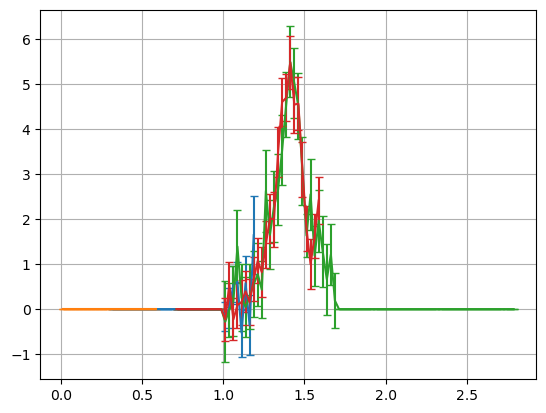

In [5]:
bin_tomo = 14
current_bin_values = data[str(bin_tomo)]
for key, value in current_bin_values.items():
    if len(current_bin_values[key]) == 0:
        print(f'No data for {key} in tomo bin {bin_tomo}')
        continue
    z, vals, errs = zip(*current_bin_values[key])
    plt.errorbar(
        z,
        vals,
        errs,
        label=tracer_trad[key],
        capsize=3
    )
plt.grid()

In [16]:
importlib.reload(inference)
merged_bins = {}
for bin_key, bin_values in data.items():
    zm, valsm, errsm = [], [], []
    for key, value in bin_values.items():
        if len(value) == 0:
            print(f'No data for {key} in tomo bin {bin_key}')
            continue
        z, vals, errs = zip(*value)
        zm.append(np.asarray(z))
        valsm.append(np.asarray(vals))
        errsm.append(np.asarray(errs))
    z_pz, n_pz, n_pz_errs = inference.merge_results(zm, valsm, errsm)
    merged_bins[bin_key] = (list(z_pz), list(n_pz), list(n_pz_errs))

with open(f'merged_bins_sc_{scale_cut[0]}_{scale_cut[1]}.json', 'w') as f:
    json.dump(merged_bins, f)

No data for ELGnotqso in tomo bin 1
No data for ELGnotqso in tomo bin 2
No data for ELGnotqso in tomo bin 3
No data for ELGnotqso in tomo bin 4
No data for ELGnotqso in tomo bin 5
No data for ELGnotqso in tomo bin 6
No data for ELGnotqso in tomo bin 7
No data for ELGnotqso in tomo bin 8
No data for ELGnotqso in tomo bin 9
No data for ELG_LOPnotqso in tomo bin 10
No data for ELG_LOPnotqso in tomo bin 11
No data for ELG_LOPnotqso in tomo bin 12
No data for ELG_LOPnotqso in tomo bin 13
No data for ELG_LOPnotqso in tomo bin 14
No data for ELG_LOPnotqso in tomo bin 15
No data for ELG_LOPnotqso in tomo bin 16
No data for ELG_LOPnotqso in tomo bin 17
No data for ELG_LOPnotqso in tomo bin 18
No data for ELG_LOPnotqso in tomo bin 19
No data for ELG_LOPnotqso in tomo bin 20
No data for ELG_LOPnotqso in tomo bin 21
No data for ELG_LOPnotqso in tomo bin 22
No data for ELG_LOPnotqso in tomo bin 23
No data for ELG_LOPnotqso in tomo bin 24


In [5]:
tracer = 'Merged'
correction_file_reader = cf.CorrFileReader(path_dictionary["HSC"])
bins_z_photo = inference._get_fine_redshift_bins(
    fr=correction_file_reader,
    tracer='HSC'
)
vals_z_photo = (bins_z_photo[:-1] + bins_z_photo[1:]) / 2
correction_file_reader = cf.CorrFileReader(path_dictionary["DESI_NGC"])
bins_z_spectro = inference._get_fine_redshift_bins(
    fr=correction_file_reader,
    tracer='Merged'
)
vals_z_spectro = (bins_z_spectro[:-1] + bins_z_spectro[1:]) / 2

In [8]:
importlib.reload(inference)
importlib.reload(comb)
importlib.reload(ct)
importlib.reload(cf)
nz = []
nz_err = []
scale_cut = [0.2, 1]
for i in range(1, len(bins_z_photo)):
    meas = inference.full_npz_tomo(
        path_dictionary=path_dictionary,
        do_bias_correction=False,
        scale_cuts=scale_cut,
        tracer='Merged',
        tomo_bin=i,
        which_patches=None
    )
    nz.append(meas[0])
    nz_err.append(meas[1])
nz = np.array(nz)
nz_err = np.array(nz_err)

Using merged method for tracer Merged and tomo bin 1.
Using merged method for tracer Merged and tomo bin 2.
Using merged method for tracer Merged and tomo bin 3.
Using merged method for tracer Merged and tomo bin 4.
Using merged method for tracer Merged and tomo bin 5.
Using merged method for tracer Merged and tomo bin 6.
Using merged method for tracer Merged and tomo bin 7.
Using merged method for tracer Merged and tomo bin 8.
Using merged method for tracer Merged and tomo bin 9.
Using merged method for tracer Merged and tomo bin 10.
Using merged method for tracer Merged and tomo bin 11.
Using merged method for tracer Merged and tomo bin 12.
Using merged method for tracer Merged and tomo bin 13.
Using merged method for tracer Merged and tomo bin 14.
Using merged method for tracer Merged and tomo bin 15.
Using merged method for tracer Merged and tomo bin 16.
Using merged method for tracer Merged and tomo bin 17.
Using merged method for tracer Merged and tomo bin 18.
Using merged method

Text(0, 0.5, 'Number density')

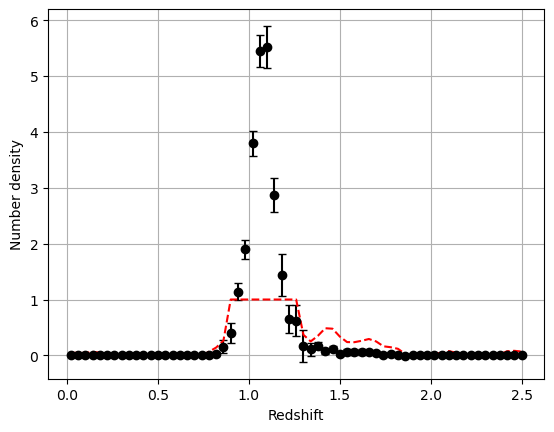

In [10]:
importlib.reload(sgp)
ind = 10
suppresion = sgp.suppression(
    zval=vals_z_photo,
    gp_n=nz[ind],
    gp_sigma=nz_err[ind]
)
mean, uncertainty = sgp.suppress_nz(
    zval=vals_z_spectro,
    gp_n=nz[ind],
    gp_sigma=nz_err[ind]
)
plt.errorbar(
    vals_z_spectro, 
    mean, 
    yerr=uncertainty, 
    fmt='o', 
    color='black', 
    label='Suppressed GP',
    capsize=3
)
plt.plot(
    vals_z_spectro, 
    suppresion, 
    color='red', 
    label='GP',
    linestyle='--'
)
plt.grid()
plt.xlabel('Redshift')
plt.ylabel('Number density')

Text(0, 0.5, 'Number density')

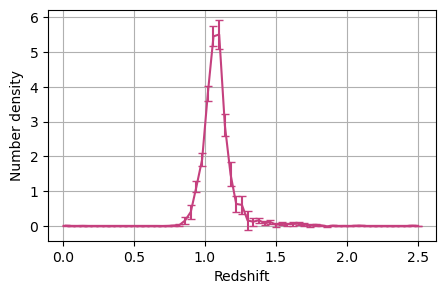

In [12]:
plt.figure(figsize=(5, 3))
colormap = plt.get_cmap('plasma')
for i in range(len(vals_z_photo)):
    if i != 10:
        continue
    plt.errorbar(
        vals_z_spectro, 
        calib_nz[i], 
        yerr=calib_nz_err[i],
        color=colormap(i / (len(vals_z_photo)-1)),
        capsize=3
    )
plt.grid()
plt.xlabel('Redshift')
plt.ylabel('Number density')

In [13]:
vals_z_wdm = np.linspace(0.01, 3, 150)
rp_wdm = np.linspace(scale_cut[0], scale_cut[1], 100)
wdm_values = np.array([
    ct.w_dm(
        rp_vals=rp_wdm,
        z=z,
        integrate=True
        )
    for z in vals_z_wdm
])
wdm_interpolator = interp.interp1d(
    vals_z_wdm, 
    wdm_values, 
    bounds_error=False, 
    fill_value='extrapolate'
)
def integrate_wdm_over_z(zlow, zhigh):
    z_array = np.linspace(zlow, zhigh, 100)
    return np.trapz(
        wdm_interpolator(z_array),
        z_array
    ) / (zhigh - zlow)

In [14]:
wdm = np.array([
    ct.w_dm(
        rp_vals=np.linspace(scale_cut[0], scale_cut[1], 100),
        z=z,
        integrate=True
        )
    for z in vals_z_spectro
])
wdm_phot = np.array([
    ct.w_dm(
        rp_vals=np.linspace(scale_cut[0], scale_cut[1], 100),
        z=z,
        integrate=True
        )
    for z in vals_z_photo
])

In [15]:
corr_factor = []
corr_factor_err = []
dz = vals_z_spectro[1] - vals_z_spectro[0]
dz_phot = vals_z_photo[1] - vals_z_photo[0]
weights_trapz = comb.trapz_weights(vals_z_spectro)

for i in range(len(vals_z_photo)):
    mean, uncertainty = sgp.suppress_nz(
        zval=vals_z_spectro,
        gp_n=nz[i],
        gp_sigma=nz_err[i]
    )
    num = (wdm_phot[i] / dz_phot)
    denom = np.trapz(np.multiply(np.array(mean)**2, wdm), x=vals_z_spectro)
    corr = num / denom
    delta_D = np.sqrt(np.sum((2 * mean * wdm * weights_trapz)**2 * uncertainty**2))
    err = num / (denom**2) * delta_D
    corr_factor.append(corr)
    corr_factor_err.append(err)

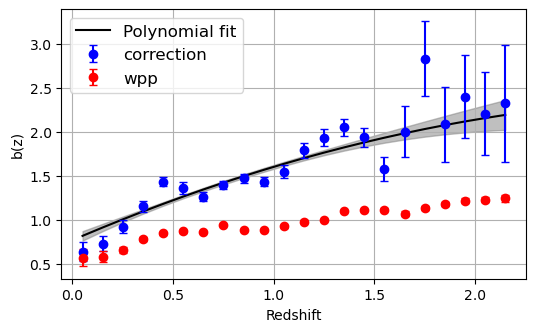

In [16]:
importlib.reload(inference)
importlib.reload(comb)
wpp_scaled = []
wpp_err_scaled = []

for i in range(1, len(vals_z_photo)+1):
    ## now let's get the wpp measurements to get the full correction
    wpp_meas, wpp_err_meas, _ = inference.wpp(
            path=path_dictionary['HSC'],
            scale_cuts=scale_cut,
            bin_index=i,
        )
    wdm_eff = ct.w_dm(
        rp_vals=np.linspace(scale_cut[0], scale_cut[1], 100),
        z=vals_z_photo[i-1],
        integrate=True
    )
    wpp_err_scaled.append(wpp_err_meas*dz_phot/wdm_eff)
    wpp_scaled.append(wpp_meas*dz_phot/wdm_eff)
    
wpp_err_scaled = np.array(wpp_err_scaled)
wpp_scaled = np.array(wpp_scaled)
bpp = np.sqrt(wpp_scaled)
bpp_err = 1/(2* wpp_scaled ** (3/2)) * wpp_err_scaled

errs = comb.combine_error_bars_mult(wpp_scaled, wpp_err_scaled, corr_factor, corr_factor_err)
vals = np.sqrt(np.array(wpp_scaled)*(np.array(corr_factor)))

# polynomial fit to vals and errs
def poly_fit(x, a, b, c):
    return a * x**2 + b * x + c
popt, pcov = opt.curve_fit(
    poly_fit, 
    vals_z_photo, 
    vals,
    sigma=errs, 
    absolute_sigma=True
)
fit_vals = poly_fit(vals_z_photo, *popt)
X = np.vstack([vals_z_photo**2, vals_z_photo, np.ones_like(vals_z_photo)]).T
fit_sigma = np.sqrt(np.sum(X @ pcov * X, axis=1))

plt.figure(figsize=(6, 3.5))
plt.fill_between(
    vals_z_photo, 
    fit_vals - fit_sigma, 
    fit_vals + fit_sigma,
    color='gray', 
    alpha=0.5, 
)
plt.plot(vals_z_photo, fit_vals, color='black', label='Polynomial fit')
plt.errorbar(vals_z_photo, vals, errs, label='correction', capsize=3, fmt='o', color='blue')
plt.errorbar(vals_z_photo, bpp, bpp_err, label='wpp', capsize=3, fmt='o', color='red')
plt.legend(loc='upper left', fontsize=12)
plt.xlabel('Redshift')
plt.ylabel('b(z)')
plt.grid()

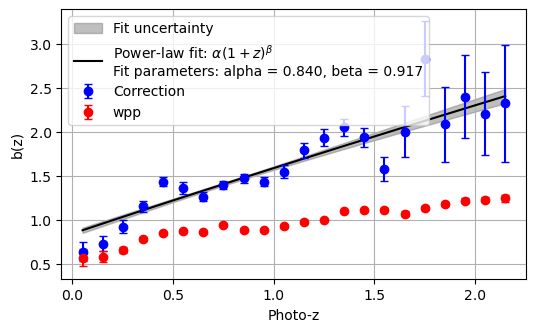

In [17]:
wpp_scaled = []
wpp_err_scaled = []

for i in range(1, len(vals_z_photo)+1):
    wpp_meas, wpp_err_meas, _ = inference.wpp(
        path=path_dictionary['HSC'],
        scale_cuts=scale_cut,
        bin_index=i,
    )
    wdm_eff = ct.w_dm(
        rp_vals=np.linspace(scale_cut[0], scale_cut[1], 100),
        z=vals_z_photo[i-1],
        integrate=True
    )
    wpp_err_scaled.append(wpp_err_meas*dz_phot/wdm_eff)
    wpp_scaled.append(wpp_meas*dz_phot/wdm_eff)

wpp_scaled = np.array(wpp_scaled)
wpp_err_scaled = np.array(wpp_err_scaled)

# Combine errors and compute final correction values
errs = comb.combine_error_bars_mult(wpp_scaled, wpp_err_scaled, corr_factor, corr_factor_err)
vals = np.sqrt(wpp_scaled * corr_factor)
bpp = np.sqrt(wpp_scaled)
bpp_err = 1/(2* wpp_scaled ** (3/2)) * wpp_err_scaled

# --- Power law: alpha * (1 + z)^beta ---
def powerlaw_1pz(z, alpha, beta):
    return alpha * (1 + z) ** beta

# Fit
popt, pcov = opt.curve_fit(powerlaw_1pz, vals_z_photo, vals, sigma=errs, absolute_sigma=True)
fit_vals = powerlaw_1pz(vals_z_photo, *popt)

# --- Uncertainty propagation ---
z = vals_z_photo
alpha, beta = popt
J = np.empty((len(z), 2))
J[:, 0] = (1 + z) ** beta                          # ∂f/∂alpha
J[:, 1] = alpha * (1 + z) ** beta * np.log(1 + z)  # ∂f/∂beta
fit_sigma = np.sqrt(np.sum(J @ pcov * J, axis=1))

plt.figure(figsize=(6, 3.5))
plt.fill_between(z, fit_vals - fit_sigma, fit_vals + fit_sigma, color='gray', alpha=0.5, label='Fit uncertainty')
plt.plot(z, 
         fit_vals, 
         color='black', 
         label='Power-law fit: $\\alpha(1+z)^\\beta$\n' 
         + f'Fit parameters: alpha = {popt[0]:.3f}, beta = {popt[1]:.3f}'
         )
plt.errorbar(z, vals, errs, fmt='o', color='blue', capsize=3, label='Correction')
plt.errorbar(z, bpp, bpp_err, fmt='o', color='red', capsize=3, label='wpp')
plt.xlabel('Photo-z')
plt.ylabel('b(z)')
plt.grid()
plt.legend()

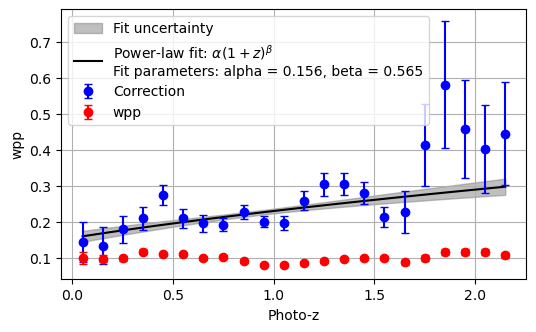

In [26]:
wpp_scaled = []
wpp_err_scaled = []

for i in range(1, len(vals_z_photo)+1):
    wpp_meas, wpp_err_meas, _ = inference.wpp(
        path=path_dictionary['HSC'],
        scale_cuts=scale_cut,
        bin_index=i,
    )
    wpp_err_scaled.append(wpp_err_meas)
    wpp_scaled.append(wpp_meas)

wpp_scaled = np.array(wpp_scaled)
wpp_err_scaled = np.array(wpp_err_scaled)

# Combine errors and compute final correction values
vals = wpp_scaled * corr_factor
errs = np.sqrt((wpp_scaled * corr_factor_err)**2 + (wpp_err_scaled * corr_factor)**2)

def powerlaw_1pz(z, alpha, beta):
    return alpha * (1 + z) ** beta

# Fit
popt, pcov = opt.curve_fit(powerlaw_1pz, vals_z_photo, vals, sigma=errs, absolute_sigma=True)
fit_vals = powerlaw_1pz(vals_z_photo, *popt)

# --- Uncertainty propagation ---
z = vals_z_photo
alpha, beta = popt
J = np.empty((len(z), 2))
J[:, 0] = (1 + z) ** beta                          # ∂f/∂alpha
J[:, 1] = alpha * (1 + z) ** beta * np.log(1 + z)  # ∂f/∂beta
fit_sigma = np.sqrt(np.sum(J @ pcov * J, axis=1))

plt.figure(figsize=(6, 3.5))
plt.fill_between(z, fit_vals - fit_sigma, fit_vals + fit_sigma, color='gray', alpha=0.5, label='Fit uncertainty')
plt.plot(z, 
         fit_vals, 
         color='black', 
         label='Power-law fit: $\\alpha(1+z)^\\beta$\n' 
         + f'Fit parameters: alpha = {popt[0]:.3f}, beta = {popt[1]:.3f}'
         )
plt.errorbar(z, vals, errs, fmt='o', color='blue', capsize=3, label='Correction')
plt.errorbar(z, wpp_scaled, wpp_err_scaled, fmt='o', color='red', capsize=3, label='wpp')
plt.xlabel('Photo-z')
plt.ylabel('wpp')
plt.grid()
plt.legend()

Fit parameters: alpha = 0.62832 ± 0.02301, beta = 0.21524 ± 0.05757


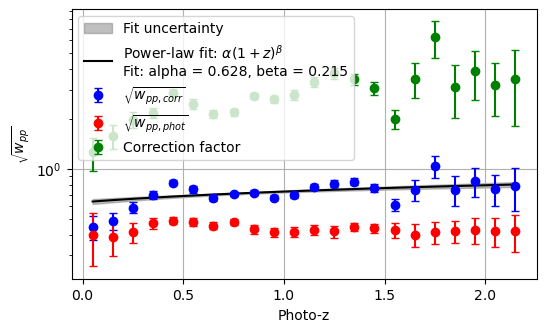

In [20]:
wpp_scaled = []
wpp_err_scaled = []

for i in range(1, len(vals_z_photo)+1):
    wpp_meas, wpp_err_meas, _ = inference.wpp(
        path=path_dictionary['HSC'],
        scale_cuts=scale_cut,
        bin_index=i,
    )
    wpp_err_scaled.append(wpp_err_meas)
    wpp_scaled.append(wpp_meas)

wpp_scaled = np.array(wpp_scaled)
wpp_err_scaled = np.array(wpp_err_scaled)
bpp = np.sqrt(wpp_scaled)
bpp_err = 1/(2* wpp_scaled ** (3/2)) * wpp_err_scaled
vals = np.sqrt(wpp_scaled * corr_factor)
errs = comb.combine_error_bars_mult(wpp_scaled, wpp_err_scaled, corr_factor, corr_factor_err)

def powerlaw_1pz(z, alpha, beta):
    return alpha * (1 + z) ** beta

# Fit
popt, pcov = opt.curve_fit(powerlaw_1pz, vals_z_photo, vals, sigma=errs, absolute_sigma=True)
fit_vals = powerlaw_1pz(vals_z_photo, *popt)

# --- Uncertainty propagation ---
z = vals_z_photo
alpha, beta = popt
J = np.empty((len(z), 2))
J[:, 0] = (1 + z) ** beta                          # ∂f/∂alpha
J[:, 1] = alpha * (1 + z) ** beta * np.log(1 + z)  # ∂f/∂beta
fit_sigma = np.sqrt(np.sum(J @ pcov * J, axis=1))

# get the error on parameters
param_errors = np.sqrt(np.diag(pcov))
print(f'Fit parameters: alpha = {popt[0]:.5f} ± {param_errors[0]:.5f}, beta = {popt[1]:.5f} ± {param_errors[1]:.5f}')

plt.figure(figsize=(6, 3.5))
plt.fill_between(z, fit_vals - fit_sigma, fit_vals + fit_sigma, color='gray', alpha=0.5, label='Fit uncertainty')
plt.plot(z, 
         fit_vals, 
         color='black', 
         label='Power-law fit: $\\alpha(1+z)^\\beta$\n' 
         + f'Fit: alpha = {popt[0]:.3f}, beta = {popt[1]:.3f}'
         )
plt.errorbar(z, vals, errs, fmt='o', color='blue', capsize=3, label=r'$\sqrt{w_{pp, corr}}$')
plt.errorbar(z, bpp, bpp_err, fmt='o', color='red', capsize=3, label=r'$\sqrt{w_{pp, phot}}$')
plt.errorbar(z, corr_factor, corr_factor_err, fmt='o', color='green', capsize=3, label=f'Correction factor')
plt.xlabel('Photo-z')
plt.yscale('log')
plt.ylabel(r'$\sqrt{w_{pp}}$')
plt.grid()
plt.legend()